# 处理空气污染数据

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

import sys
import os
import geopandas as gpd
import xarray as xr

plt.rcParams['axes.facecolor'] = 'white'
sns.set_style('white')

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [5]:
folder = r"data/PM2.5_monthly/CHAP_PM2.5_M1K_2000_V4/"
f1 = r"CHAP_PM2.5_M1K_200001_V4.nc"
filepath = os.path.join(folder, f1)
filepath

'data/PM2.5_monthly/CHAP_PM2.5_M1K_2000_V4/CHAP_PM2.5_M1K_200001_V4.nc'

In [6]:
pm25 = xr.open_dataset(filepath)
pm25

<xarray.Dataset>
Dimensions:  (lat: 3571, lon: 6148)
Coordinates:
  * lat      (lat) float32 53.67 53.66 53.65 53.64 ... 18.0 17.99 17.98 17.97
  * lon      (lon) float32 73.46 73.47 73.48 73.49 ... 134.9 134.9 134.9 134.9
Data variables:
    PM2.5    (lat, lon) float32 ...

In [7]:
county = gpd.read_file("中国行政区划2019/县.shp").to_crs("EPSG:4326")
county.crs
county

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

,PAC,NAME,省代码,省,市代码,市,类型,geometry
0,110101,东城区,110000,北京市,110000,北京市,市辖区,"POLYGON ((116.40581 39.96245, 116.40783 39.960..."
1,110102,西城区,110000,北京市,110000,北京市,市辖区,"POLYGON ((116.38139 39.96006, 116.38053 39.956..."
2,110105,朝阳区,110000,北京市,110000,北京市,市辖区,"MULTIPOLYGON (((116.48030 40.07965, 116.48970 ..."
3,110106,丰台区,110000,北京市,110000,北京市,市辖区,"POLYGON ((116.31980 39.89578, 116.31978 39.894..."
4,110107,石景山区,110000,北京市,110000,北京市,市辖区,"POLYGON ((116.14485 39.99233, 116.14568 39.991..."
...,...,...,...,...,...,...,...,...
2895,710210,前镇区,710000,台湾省,710200,台北市,不统计,"POLYGON ((120.32254 22.61569, 120.32342 22.613..."
2896,710211,旗津区,710000,台湾省,710200,台北市,不统计,"POLYGON ((120.27170 22.61347, 120.27464 22.611..."
2897,710212,小港区,710000,台湾省,710200,台北市,不统计,"POLYGON ((120.36048 22.50767, 120.35556 22.510..."
2898,810000,香港特别行政区,810000,香港特别行政区,810000,香港特别行政区,不统计,"MULTIPOLYGON (((113.91455 22.16283, 113.91516 ..."


In [8]:
county[county['类型'] != '不统计'].count()

PAC         2852
NAME        2852
省代码         2852
省           2852
市代码         2852
市           2852
类型          2852
geometry    2852
dtype: int64

<AxesSubplot: >

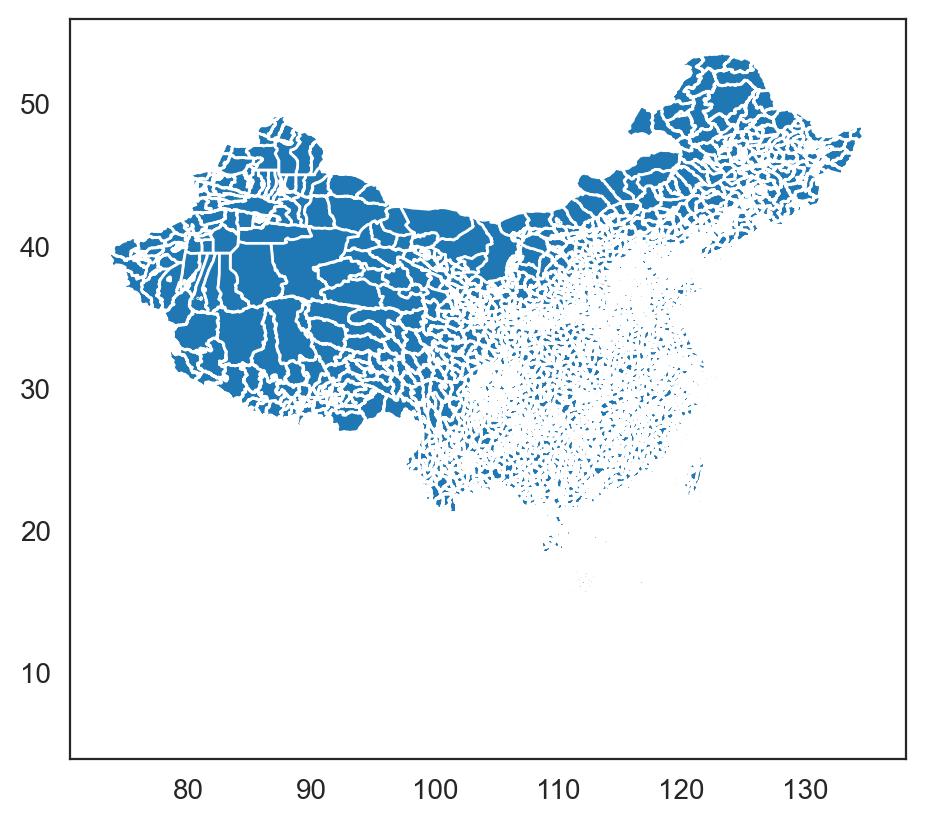

In [9]:
county.plot()

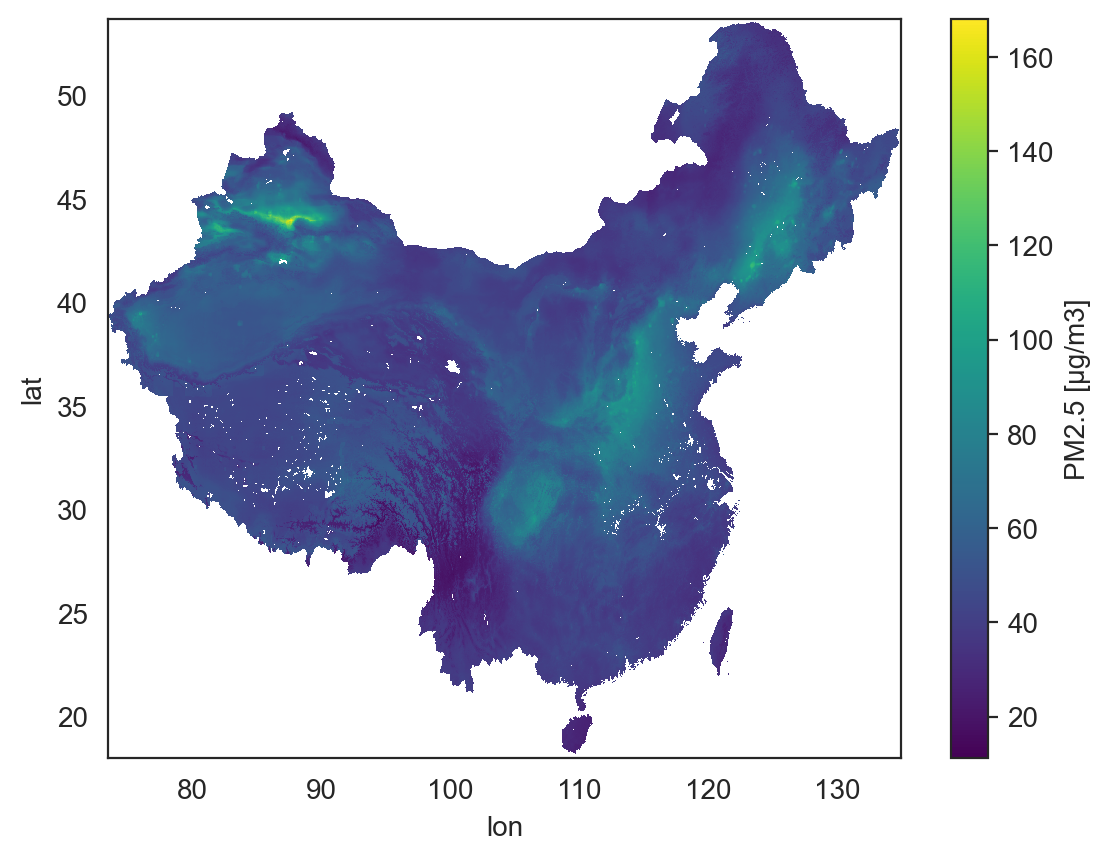

In [11]:
pm25['PM2.5'].to

In [34]:

import os
from osgeo import gdal
import netCDF4 as nc
import numpy as np  
from glob import glob
from osgeo import osr

#Define work and output paths
WorkPath = r'data/PM2.5_yearly/'
OutPath  = WorkPath

#Define air pollutant type 
#e.g., PM1, PM2.5, PM10, O3, NO2, SO2, and CO, et al.
AP = 'PM2.5'

#Define spatial resolution 
#e.g., 1 km ≈ 0.01 Degree
SP = 0.01 #Degrees

if not os.path.exists(OutPath):
    os.makedirs(OutPath)
path = glob(os.path.join(WorkPath, '*.nc'))

for file in path:
    f = nc.Dataset(file)   
    #Read SDS data
    data = np.array(f[AP][:]) 
    #Define missing value: NaN or -999
    data[data==65535] = np.nan #-999 
    #Read longitude and latitude information
    lon = np.array(f['lon'][:])
    lat = np.array(f['lat'][:])        
    LonMin,LatMax,LonMax,LatMin = lon.min(),lat.max(),lon.max(),lat.min()    
    N_Lat = len(lat) 
    N_Lon = len(lon)
    Lon_Res = SP #round((LonMax-LonMin)/(float(N_Lon)-1),2)
    Lat_Res = SP #round((LatMax-LatMin)/(float(N_Lat)-1),2)
    #Define Define output file
    fname = os.path.basename(file).split('.nc')[0]
    outfile = OutPath + '/{}.tif' .format(fname)        
    #Write GeoTIFF
    driver = gdal.GetDriverByName('GTiff')    
    outRaster = driver.Create(outfile,N_Lon,N_Lat,1,gdal.GDT_Float32)
    outRaster.SetGeoTransform([LonMin-Lon_Res/2,Lon_Res,0,LatMax+Lat_Res/2,0,-Lat_Res])
    sr = osr.SpatialReference()
    sr.SetWellKnownGeogCS('WGS84')
    outRaster.SetProjection(sr.ExportToWkt())
    outRaster.GetRasterBand(1).WriteArray(data)
    print(fname+'.tif',' Finished')     
    #release memory
    del outRaster
    f.close()

0

0

0

0

CHAP_PM2.5_Y1K_2006_V4.tif  Finished


...

0

0

0

0

CHAP_PM2.5_Y1K_2013_V4.tif  Finished


In [40]:
from rasterstats import zonal_stats
import rasterio as rio

new_df = county[['PAC', 'NAME']].copy()


path = glob(os.path.join(WorkPath, '*.tif'))

for yr in range(2000, 2022):
    filename = f'data/PM2.5_yearly/CHAP_PM2.5_Y1K_{yr}_V4.tif'
    stats = zonal_stats(
        county,
        filename,
        nodata=nodata,
        stats=list(to_stats.keys())
    )
    df = pd.DataFrame(stats)
    df = df.rename({col: f"{col}_{yr}" for col in df}, axis=1)
    new_df = pd.concat([new_df, df], axis=1)

new_df

,PAC,NAME,min_2000,max_2000,mean_2000,min_2001,max_2001,mean_2001,min_2002,max_2002,...,mean_2018,min_2019,max_2019,mean_2019,min_2020,max_2020,mean_2020,min_2021,max_2021,mean_2021
0,110101,东城区,72.700005,75.599998,74.006825,77.599998,80.400002,78.899997,78.500000,81.300003,...,50.931818,43.600002,45.200001,44.418185,38.700001,39.799999,39.077276,33.799999,35.900002,35.068182
1,110102,西城区,73.099998,76.400002,74.801853,77.599998,80.500000,79.185185,78.300003,81.200005,...,50.970373,43.000000,45.000000,44.111111,38.299999,39.700001,38.935185,34.700001,35.600002,35.094446
2,110105,朝阳区,67.700005,76.400002,72.744061,71.200005,81.500000,76.970079,73.500000,82.300003,...,50.842825,42.299999,46.400002,44.459425,37.900002,41.100002,39.478892,34.200001,37.299999,35.535861
3,110106,丰台区,59.000000,76.200005,71.874539,62.100002,81.000000,76.028530,64.900002,82.400002,...,51.669323,41.799999,46.400002,45.134972,38.500000,41.900002,40.340185,32.600002,37.000000,35.192946
4,110107,石景山区,59.900002,72.599998,68.744088,63.200001,76.099998,71.681725,64.400002,78.300003,...,50.858062,40.900002,44.700001,43.240862,37.799999,40.600002,39.467742,33.100002,35.500000,34.494624
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2895,710210,前镇区,31.200001,42.900002,36.105557,33.200001,44.000000,37.488892,32.500000,42.400002,...,27.016666,23.500000,30.500000,25.916667,19.000000,23.400000,20.916667,18.500000,20.400000,19.670001
2896,710211,旗津区,39.600002,39.600002,39.600002,41.100002,41.100002,41.100002,39.900002,39.900002,...,29.100000,29.100000,29.100000,29.100000,24.800001,24.800001,24.800001,20.300001,20.500000,20.400002
2897,710212,小港区,28.700001,36.100002,31.867570,31.000000,37.200001,33.994596,30.000000,36.100002,...,24.272974,21.100000,26.300001,23.186487,17.500000,22.600000,19.032433,17.300001,19.700001,18.564866
2898,810000,香港特别行政区,25.800001,35.100002,28.528768,28.700001,38.799999,32.105889,27.200001,37.600002,...,25.186412,20.700001,31.200001,23.478257,17.300001,27.500000,18.877690,15.300000,21.800001,18.089308


In [41]:
new_df.to_csv("Yearly_PM25_2000_2021.csv")